# Аналіз маркетингової кампанії банку
## Прогнозування підписки на строковий депозит — Повний наскрізний аналіз

**Виконавець:** Сімоненко Анастасія

**Мета роботи:** Проаналізувати дані телефонних маркетингових кампаній банку та побудувати модель машинного навчання, яка прогнозує, чи погодиться клієнт оформити строковий депозит.

**Набір даних:** 45 211 записів | 16 ознак | Бінарна цільова змінна (`y`: підписався на депозит чи ні)

**Структура роботи:**
1. Завантаження та початкова перевірка даних
2. Очищення даних та обробка пропущених значень
3. Розвідувальний аналіз даних (EDA)
4. Конструювання ознак (Feature Engineering)
5. Побудова та оцінка моделей (7 класифікаторів)
6. Висновки та маркетингові рекомендації

---
## Крок 1. Завантаження та початкова перевірка даних

**Обґрунтування:** Перший крок будь-якого аналізу — завантажити дані та зрозуміти їхню структуру. Без цього неможливо спланувати подальші кроки. Потрібно перевірити форму датасету, типи змінних, наявність пропущених значень та загальну картину даних. Саме на цьому етапі виявляється, чи є проблеми з якістю даних, які потребують подальшої обробки.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

df = pd.read_csv('data.txt', sep='\t')
print(f'Розмір датасету: {df.shape}')
print(f'Стовпці: {list(df.columns)}')
df.head()

In [ ]:
print('=== Типи даних ===')
print(df.dtypes)
print('\n=== Пропущені значення (явні NaN) ===')
print(df.isnull().sum())
print('\n=== Описова статистика числових ознак ===')
df.describe()

---
## Крок 2. Очищення даних та обробка пропущених значень

**Обґрунтування:** Якість моделі безпосередньо залежить від якості вхідних даних. У цьому датасеті явних NaN немає, але є приховані пропуски у вигляді рядка `'unknown'` в категоріальних колонках та значення `-1` у `pdays` (означає «клієнт ніколи не контактувався раніше»). Ігнорування цих особливостей призведе до помилкових висновків. Кожен випадок обробляється індивідуально відповідно до бізнес-логіки — це кращий підхід, ніж механічне видалення рядків, яке призвело б до втрати значної частини даних.

In [ ]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("=== Кількість значень 'unknown' у категоріальних колонках ===")
for col in cat_cols:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f'  {col:15s}: {n:5d} ({n/len(df)*100:.1f}%)')

In [ ]:
df_clean = df.copy()

# contact: замінюємо 'unknown' модою (cellular переважає серед відомих значень)
mode_contact = df_clean.loc[df_clean['contact'] != 'unknown', 'contact'].mode()[0]
df_clean['contact'].replace('unknown', mode_contact, inplace=True)

# poutcome 'unknown' → 'not_contacted' (клієнт не брав участі в попередній кампанії)
df_clean['poutcome'].replace('unknown', 'not_contacted', inplace=True)

# education та job: замінюємо модою відомих значень
for col in ['education', 'job']:
    mv = df_clean.loc[df_clean[col] != 'unknown', col].mode()[0]
    df_clean[col].replace('unknown', mv, inplace=True)

# pdays: -1 означає 'не контактувався раніше' → створюємо бінарний прапор, нуль замість -1
df_clean['previously_contacted'] = (df_clean['pdays'] != -1).astype(int)
df_clean['pdays'] = df_clean['pdays'].replace(-1, 0)

dups = df_clean.duplicated().sum()
print(f'Дублікатів рядків: {dups}')

# Кодування цільової змінної у числовий формат для аналізу
df_clean['y_bin'] = (df_clean['y'] == 'yes').astype(int)
print(f'\nРозподіл класів:')
print(df_clean['y_bin'].value_counts())
print(f'Частка позитивного класу: {df_clean["y_bin"].mean()*100:.1f}%')

---
## Крок 3. Розвідувальний аналіз даних (EDA)

**Обґрунтування:** EDA — це «діагностика» даних перед моделюванням. Необхідно зрозуміти розподіл цільової змінної, взаємозв'язки між ознаками та цільовою змінною, кореляційну структуру. Це дозволяє приймати обґрунтовані рішення щодо конструювання ознак та вибору алгоритмів, а не діяти наосліп.

### 3.1 Розподіл цільової змінної — дисбаланс класів

**Висновок:** Лише **21.7%** клієнтів підписалися на депозит. Цей дисбаланс необхідно враховувати при навчанні моделей через `class_weight='balanced'` та `scale_pos_weight`. Без врахування дисбалансу модель буде просто передбачати «не підписався» для всіх клієнтів та отримувати хибно-високу точність.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df_clean['y'].value_counts()

axes[0].pie(counts.values, labels=['Не підписався', 'Підписався'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90,
            explode=(0, 0.05), textprops={'fontsize': 12})
axes[0].set_title('Розподіл цільової змінної', fontsize=14, fontweight='bold')

bars = axes[1].bar(['Не підписався', 'Підписався'], counts.values,
                   color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Кількість спостережень за класами', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Кількість клієнтів')

plt.tight_layout()
plt.savefig('fig_01_target.png', dpi=150, bbox_inches='tight')
plt.show()

**Рис. 1: Розподіл цільової змінної**

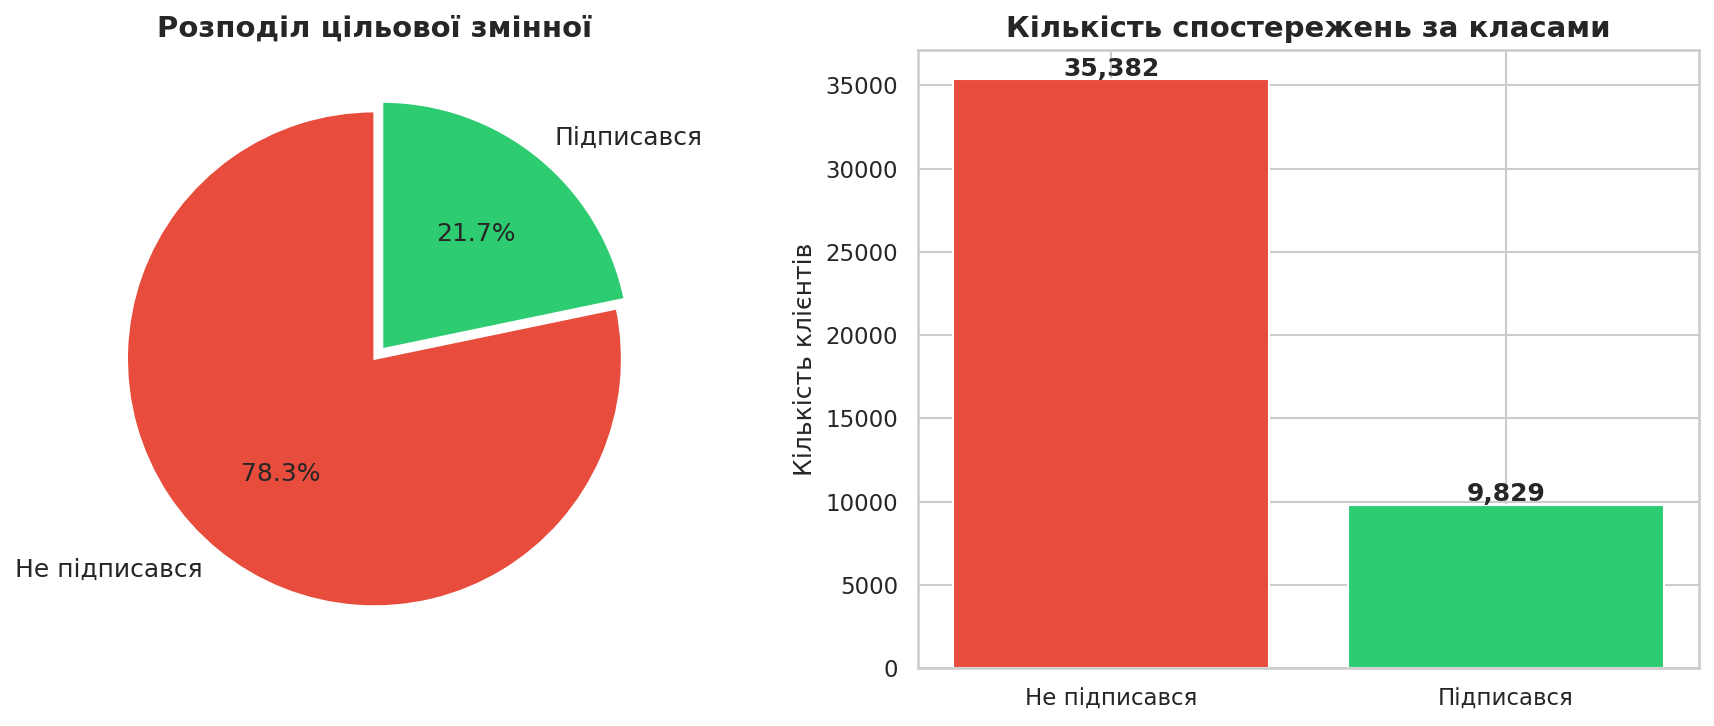

### 3.2 Розподіл числових ознак за класом цільової змінної

**Обґрунтування:** Порівняння розподілів для двох класів дозволяє виявити ознаки з найбільшою розділяючою здатністю. Якщо розподіли суттєво перекриваються — ознака слабка; якщо є чітке зміщення між класами — ознака важлива для моделі.

**Ключовий висновок:** `duration` (тривалість дзвінка) показує найчіткіше розділення між класами — підписники стабільно мають довші дзвінки.

In [ ]:
num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
col_labels = {
    'age': 'Вік (роки)', 'balance': 'Баланс рахунку (євро)',
    'duration': 'Тривалість дзвінка (сек)', 'campaign': 'Кількість контактів',
    'pdays': 'Днів з останнього контакту', 'previous': 'Попередні контакти'
}
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    for label, color in zip(['no', 'yes'], ['#e74c3c', '#2ecc71']):
        subset = df_clean.loc[df_clean['y'] == label, col]
        ax.hist(subset, bins=40, alpha=0.6, color=color, edgecolor='none',
                label='Не підписався' if label == 'no' else 'Підписався', density=True)
    ax.set_title(col_labels.get(col, col), fontsize=12, fontweight='bold')
    ax.set_xlabel('Значення'); ax.set_ylabel('Щільність')
    ax.legend(fontsize=9)
plt.suptitle('Розподіл числових ознак за класом цільової змінної',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_02_numeric.png', dpi=150, bbox_inches='tight')
plt.show()

**Рис. 2: Розподіл числових ознак за класом**

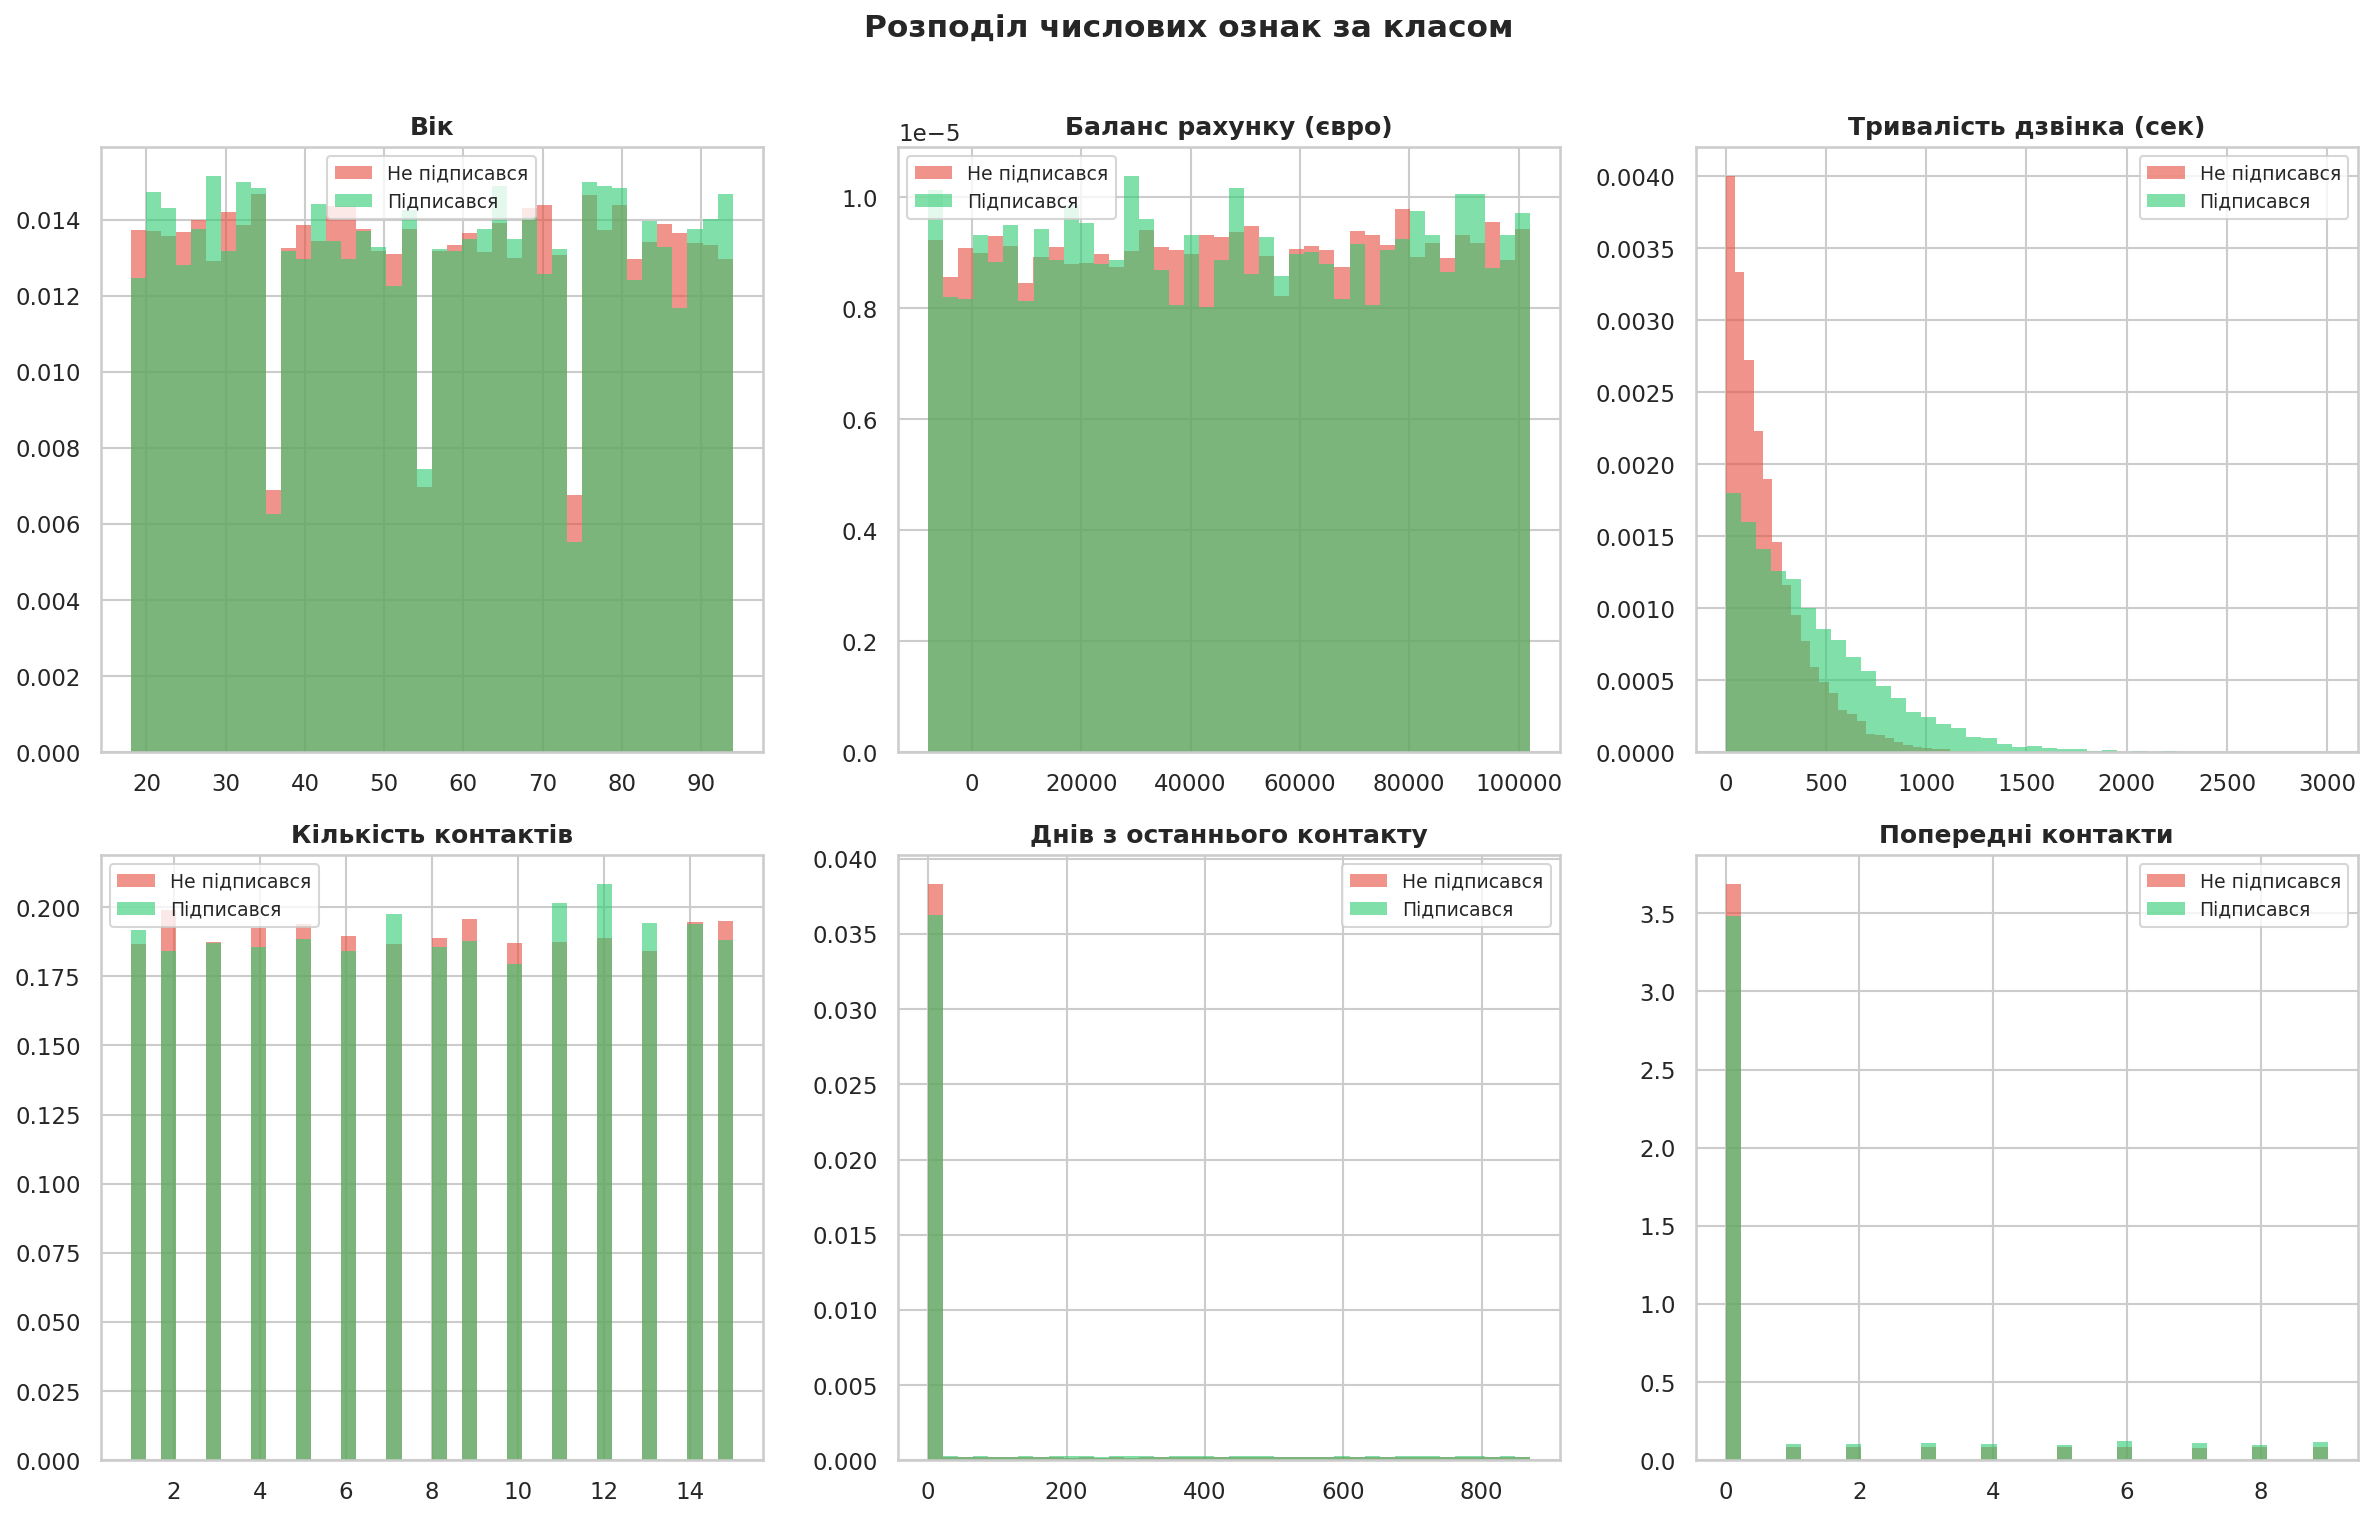

### 3.3 Частка підписок за категоріальними ознаками

**Обґрунтування:** Для категоріальних змінних найінформативніше — переглянути частку конверсії в кожній категорії. Це дає прямий бізнес-висновок: які сегменти клієнтів найбільш схильні до підписки.

**Ключові спостереження:**
- `poutcome = success` дає найвищу конверсію (понад 60%)
- Cellular-контакт суттєво ефективніший за telephone
- Місяці березень, вересень, жовтень, грудень показують найкращу конверсію
- Студенти та пенсіонери підписуються вище за середнє

In [ ]:
cat_features = ['job', 'marital', 'education', 'contact', 'poutcome', 'month']
cat_labels_map = {'job': 'Професія', 'marital': 'Сімейний стан', 'education': 'Освіта',
                  'contact': 'Спосіб контакту', 'poutcome': 'Результат попередньої кампанії', 'month': 'Місяць'}

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()
for ax, col in zip(axes, cat_features):
    rates = df_clean.groupby(col)['y_bin'].mean().sort_values(ascending=True)
    colors_bar = ['#2ecc71' if v >= rates.mean() else '#e74c3c' for v in rates.values]
    bars = ax.barh(rates.index, rates.values * 100, color=colors_bar, edgecolor='white')
    ax.axvline(rates.mean()*100, color='navy', linestyle='--', linewidth=1.5,
               label=f'Сер: {rates.mean()*100:.1f}%')
    for bar, val in zip(bars, rates.values):
        ax.text(val*100+0.3, bar.get_y()+bar.get_height()/2,
                f'{val*100:.1f}%', va='center', fontsize=9)
    ax.set_title(f'Частка підписок: {cat_labels_map.get(col,col)}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Частка підписок (%)'); ax.legend(fontsize=9)
plt.suptitle('Частка підписок за категоріальними ознаками',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_03_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

**Рис. 3: Частка підписок за категоріальними ознаками**

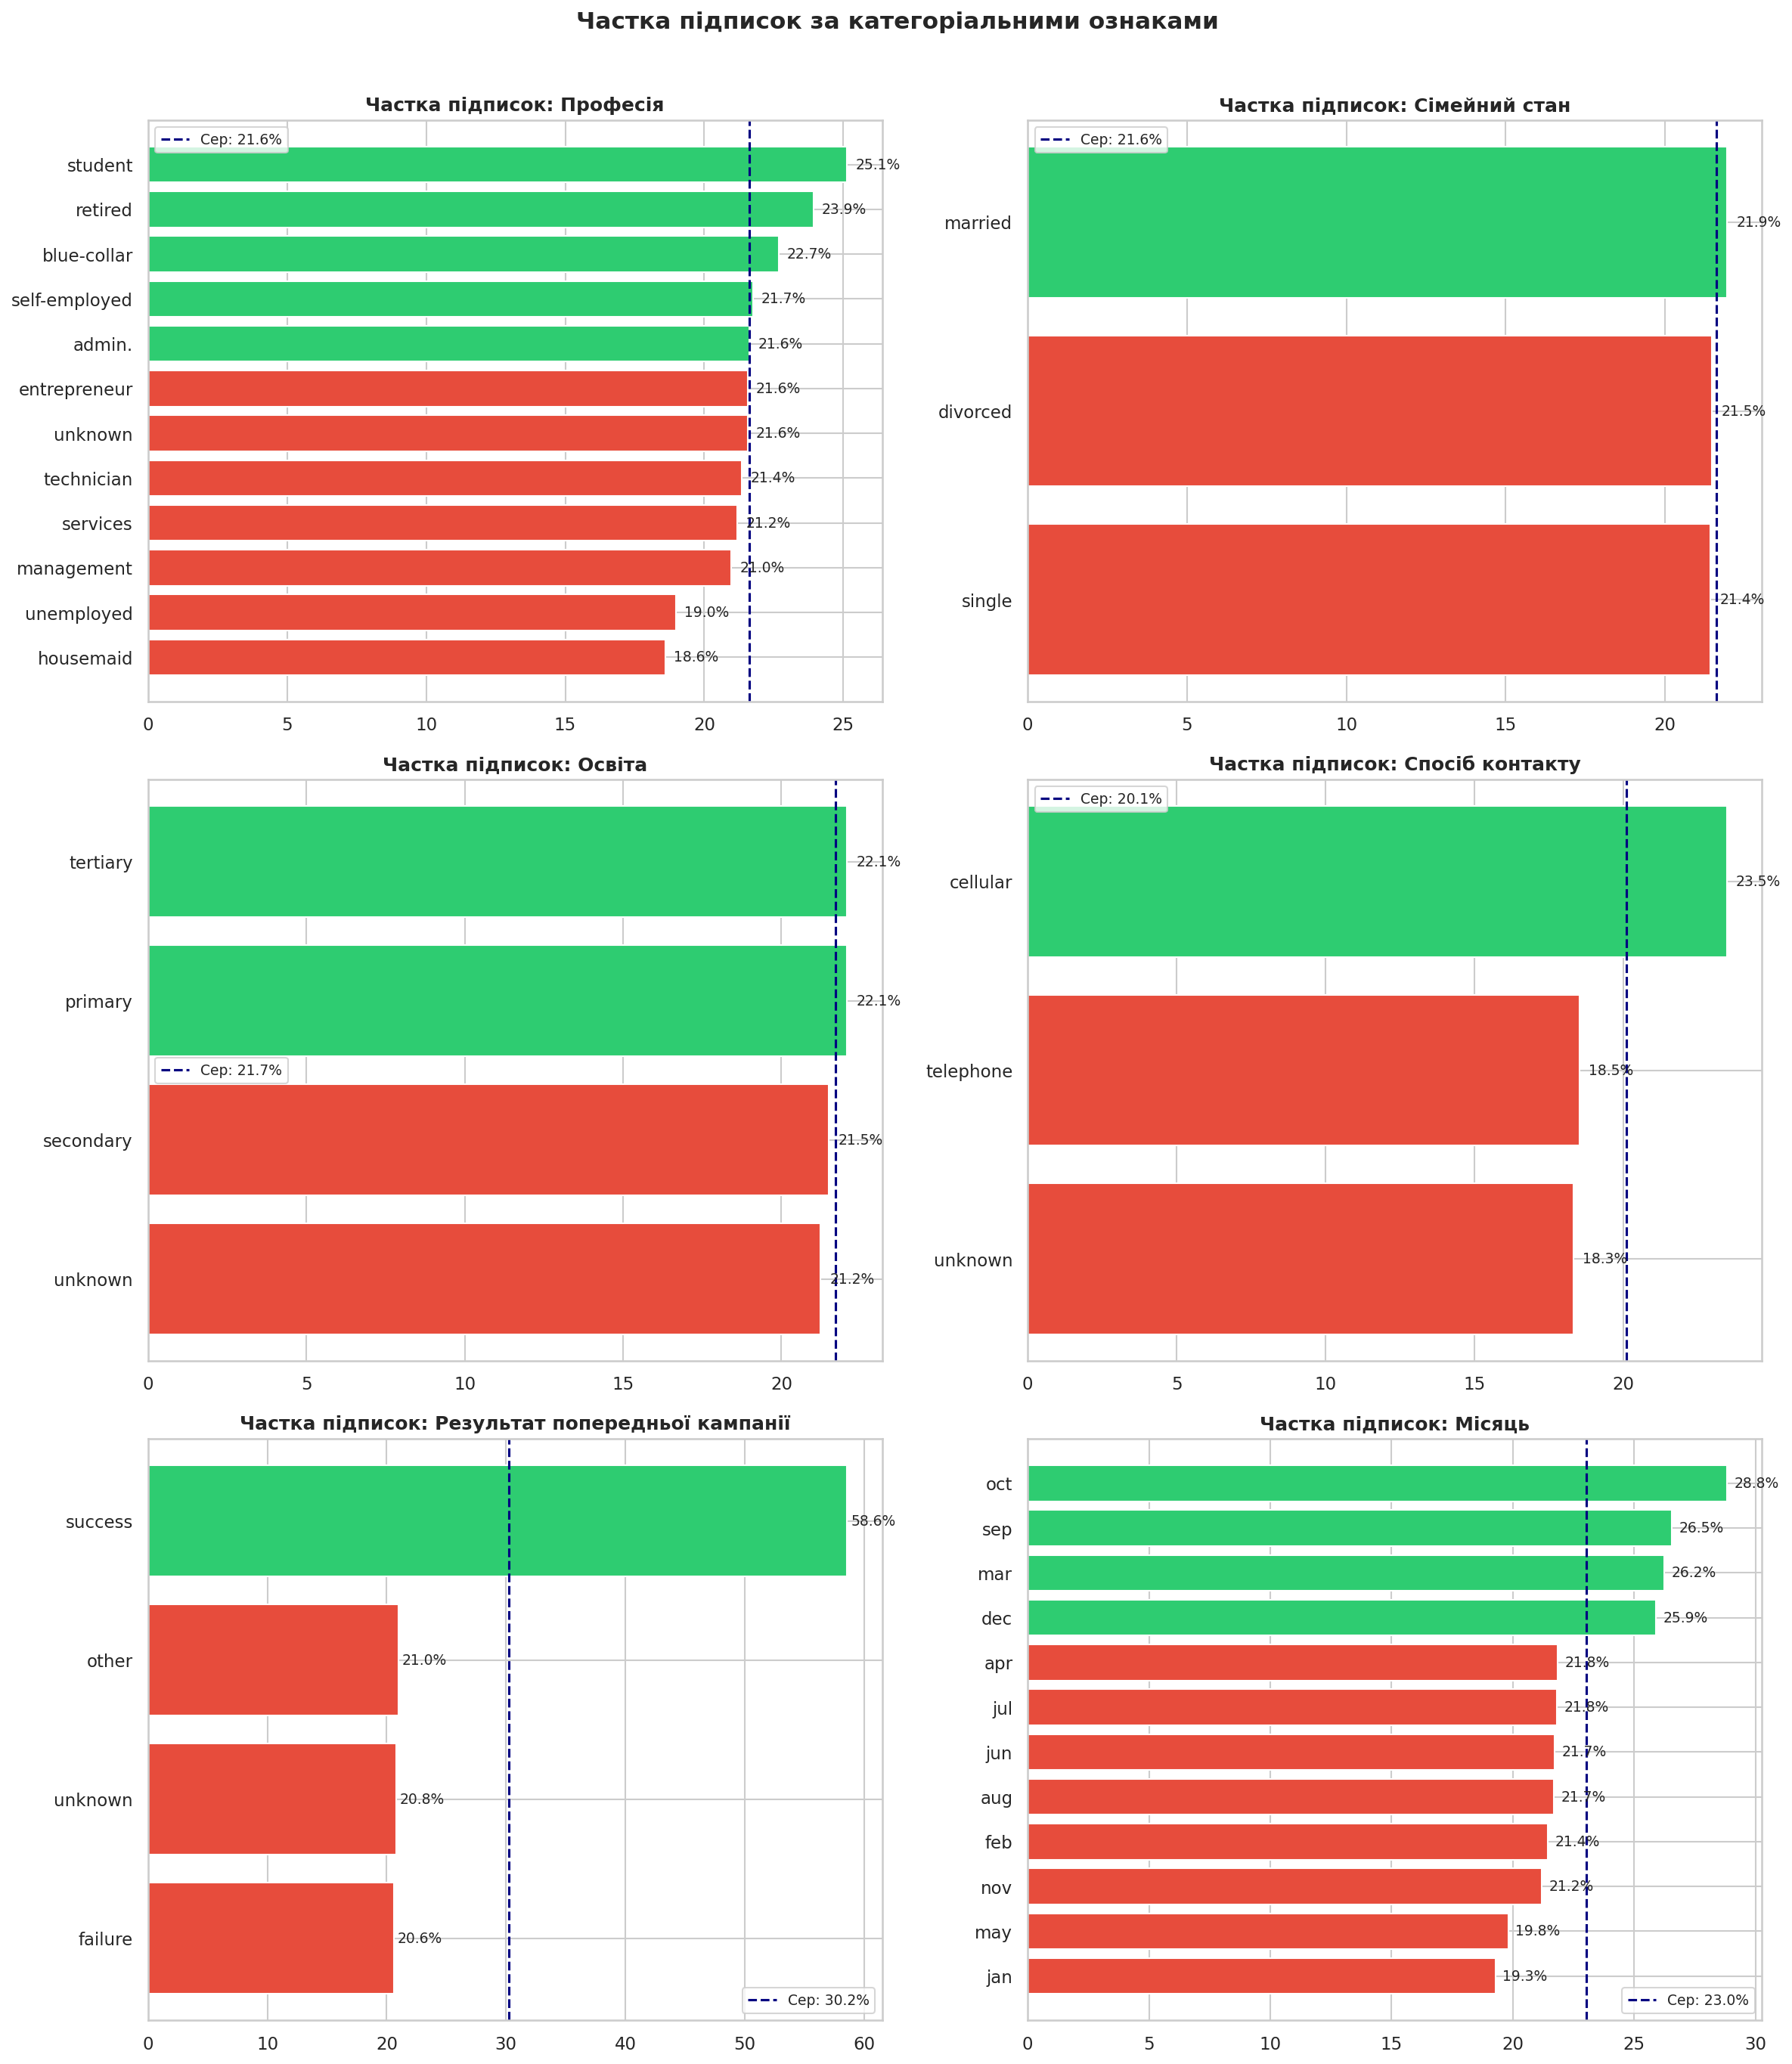

### 3.4 Теплова карта кореляцій числових ознак

**Обґрунтування:** Кореляційний аналіз виявляє мультиколінеарність між ознаками. Сильно корельовані предиктори несуть дублюючу інформацію і можуть погіршити роботу деяких алгоритмів. Нижньотрикутна форма матриці використовується для уникнення дублювання інформації.

In [ ]:
num_for_corr = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'y_bin']
corr_labels_map = {'age':'Вік','balance':'Баланс','duration':'Тривалість дзвінка',
                   'campaign':'Контакти','pdays':'Дні з контакту',
                   'previous':'Попередні контакти','y_bin':'Підписався'}
corr_data = df_clean[num_for_corr].rename(columns=corr_labels_map)
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_data.corr(), dtype=bool))
sns.heatmap(corr_data.corr(), mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Теплова карта кореляцій числових ознак', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_04_corr.png', dpi=150, bbox_inches='tight')
plt.show()

**Рис. 4: Теплова карта кореляцій**

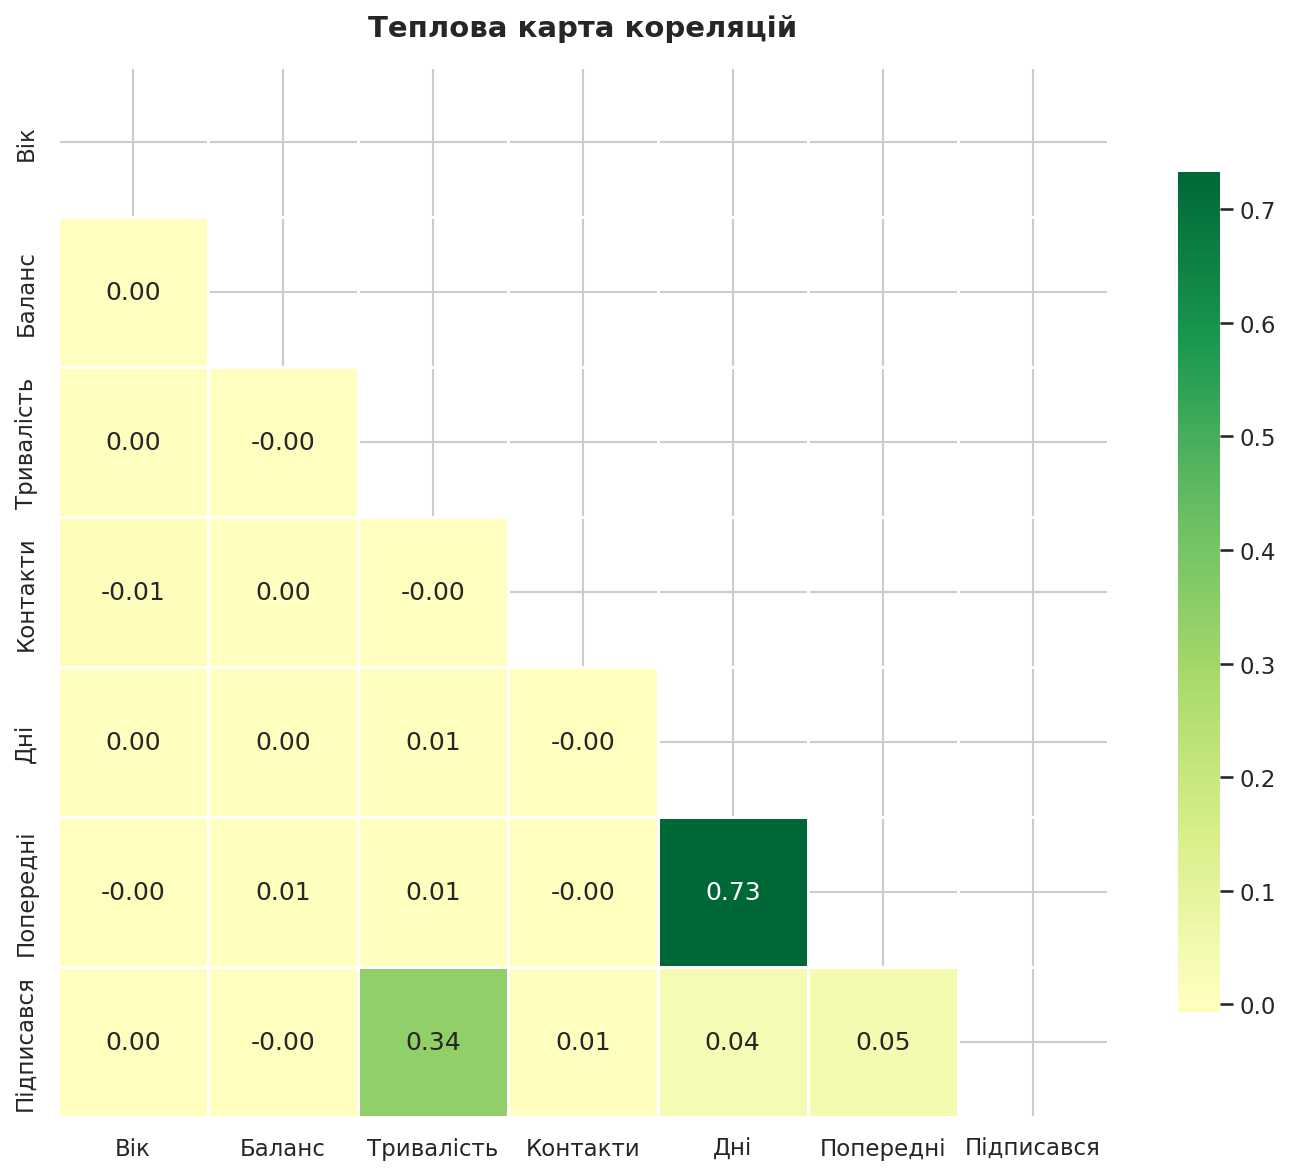

### 3.5 Аналіз тривалості дзвінків та кількості контактів

**Обґрунтування:** Тривалість дзвінка — найсильніший прогностичний сигнал. Важливо також проаналізувати «точку насичення» кількості контактів, після якої подальші дзвінки стають неефективними та шкодять бренду.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

data_yes = df_clean.loc[df_clean['y'] == 'yes', 'duration'] / 60
data_no  = df_clean.loc[df_clean['y'] == 'no',  'duration'] / 60

parts = axes[0].violinplot([data_no.values, data_yes.values],
                            positions=[1, 2], showmedians=True)
for pc, color in zip(parts['bodies'], ['#e74c3c', '#2ecc71']):
    pc.set_facecolor(color); pc.set_alpha(0.7)
parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(['Не підписався', 'Підписався'], fontsize=11)
axes[0].set_ylabel('Тривалість дзвінка (хвилини)')
axes[0].set_title('Тривалість дзвінка за класом\n(чорна лінія — медіана)', fontsize=12, fontweight='bold')
axes[0].annotate(
    f'Медіана (yes): {data_yes.median():.1f} хв\nМедіана (no): {data_no.median():.1f} хв',
    xy=(0.05, 0.95), xycoords='axes fraction', va='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

camp_rate = (df_clean[df_clean['campaign'] <= 10]
             .groupby('campaign')['y_bin'].agg(['mean','count']).reset_index())
camp_rate.columns = ['campaign', 'rate', 'count']
ax2b = axes[1].twinx()
axes[1].bar(camp_rate['campaign'], camp_rate['rate']*100, color='#3498db', alpha=0.7, label='Частка підписок (%)')
ax2b.plot(camp_rate['campaign'], camp_rate['count'], color='#e74c3c', marker='o', linewidth=2, label='Кількість клієнтів')
axes[1].set_xlabel('Кількість контактів у кампанії')
axes[1].set_ylabel('Частка підписок (%)', color='#3498db')
ax2b.set_ylabel('Кількість клієнтів', color='#e74c3c')
axes[1].set_title('Конверсія за кількістю контактів', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_05_duration_campaign.png', dpi=150, bbox_inches='tight')
plt.show()

**Рис. 5: Тривалість дзвінків та кількість контактів**

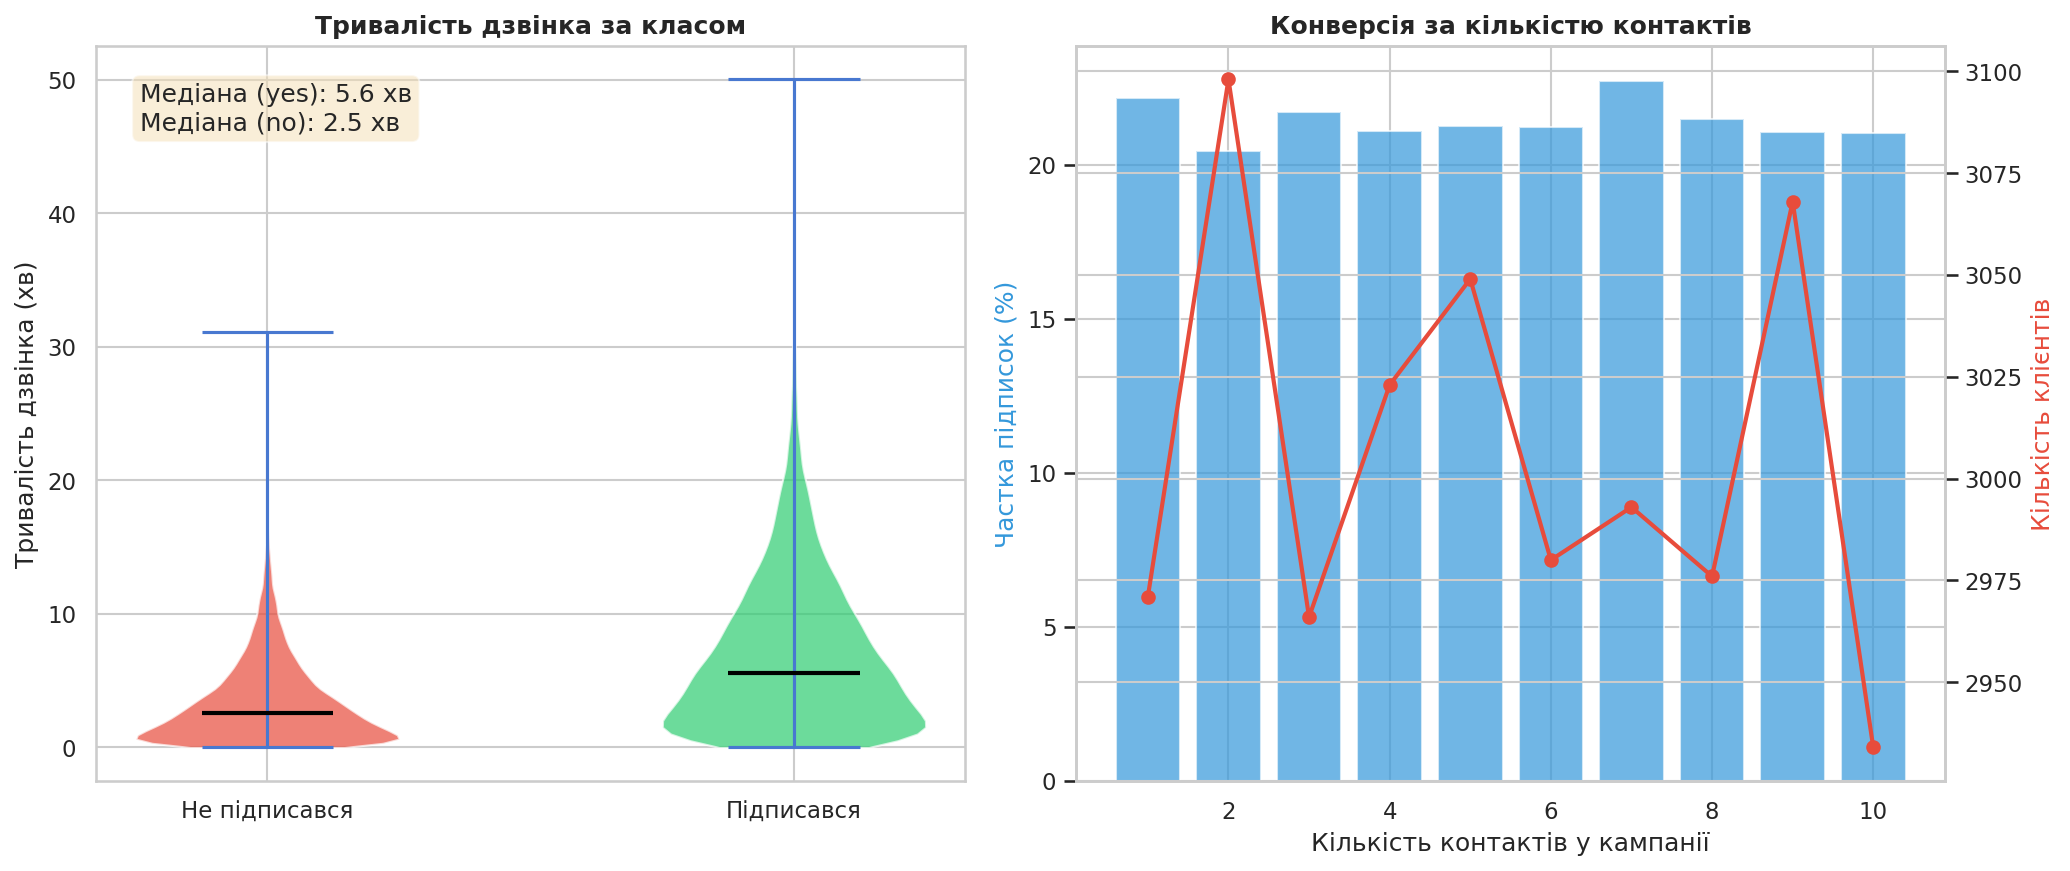

---
## Крок 4. Конструювання ознак (Feature Engineering)

**Обґрунтування:** Сирі дані рідко є оптимальними для моделей машинного навчання. Конструювання ознак дозволяє:
- Перетворити числові змінні у більш інтерпретовані одиниці (`duration_min`)
- Створити бінарні прапори для сильних нелінійних сигналів (`long_call`, `prev_success`)
- Об'єднати споріднені ознаки (`any_loan`) — зменшує розмірність без втрати інформації
- Додати сезонність (`season`) для врахування часових патернів

| Нова ознака | Логіка | Обґрунтування |
|---|---|---|
| `duration_min` | `duration / 60` | Більш інтерпретована одиниця (хвилини) |
| `long_call` | `duration > 300 с` | Бінарний прапор залучених, тривалих дзвінків |
| `any_loan` | housing АБО personal loan | Загальне боргове навантаження клієнта |
| `prev_success` | `poutcome == 'success'` | Найсильніший сигнал від попередніх кампаній |
| `previously_contacted` | `pdays != -1` | Чи контактувались з клієнтом раніше |
| `season` | місяць → пора року | Сезонні тренди конверсії |

In [ ]:
df_fe = df_clean.copy()
df_fe['duration_min'] = df_fe['duration'] / 60
df_fe['long_call']    = (df_fe['duration'] > 300).astype(int)
df_fe['any_loan']     = ((df_fe['housing'] == 'yes') | (df_fe['loan'] == 'yes')).astype(int)
df_fe['prev_success'] = (df_fe['poutcome'] == 'success').astype(int)

month_season = {
    'dec': 'зима', 'jan': 'зима', 'feb': 'зима',
    'mar': 'весна', 'apr': 'весна', 'may': 'весна',
    'jun': 'літо', 'jul': 'літо', 'aug': 'літо',
    'sep': 'осінь', 'oct': 'осінь', 'nov': 'осінь'
}
df_fe['season'] = df_fe['month'].map(month_season)

print('Нові ознаки успішно додано.')
print(df_fe[['long_call','any_loan','prev_success','previously_contacted','season']].head(5))

In [ ]:
new_bin_feats = {
    'long_call': 'Довгий дзвінок (>5 хв)',
    'any_loan': 'Має кредит',
    'prev_success': 'Попередня кампанія успішна',
    'previously_contacted': 'Контактувались раніше'
}
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (col, label) in zip(axes, new_bin_feats.items()):
    rates = df_fe.groupby(col)['y_bin'].mean() * 100
    bars = ax.bar(['Ні','Так'], rates.values, color=['#e74c3c','#2ecc71'], edgecolor='white')
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Частка підписок (%)')
    ax.set_ylim(0, rates.max() * 1.3)
plt.suptitle('Конверсія за сконструйованими бінарними ознаками',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_06_engineered.png', dpi=150, bbox_inches='tight')
plt.show()

**Рис. 6: Конверсія за сконструйованими ознаками**

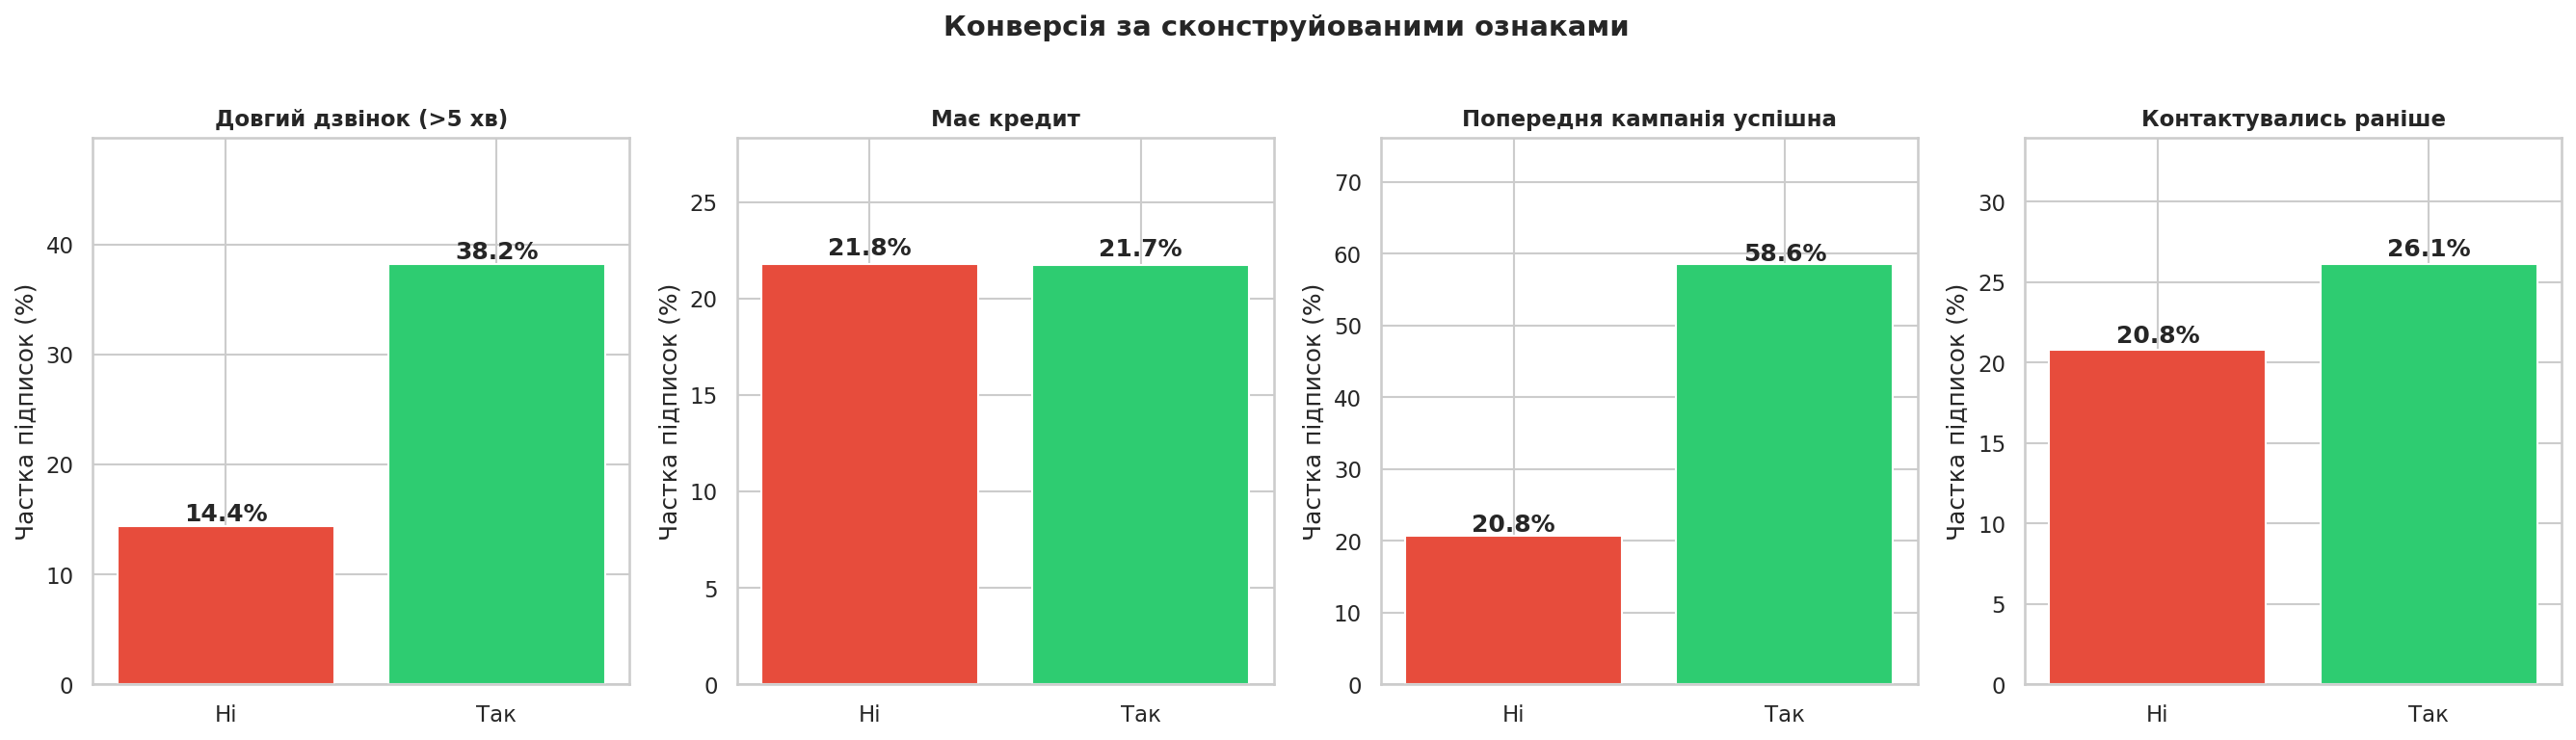

---
## Крок 5. Побудова та оцінка моделей

**Обґрунтування стратегії:**
- **7 різноманітних класифікаторів**: охоплює прості (LR, NB), середні (DT, KNN) та складні ансамблеві (RF, GB, XGB) моделі для об'єктивного порівняння
- **Дисбаланс класів**: `class_weight='balanced'` та `scale_pos_weight` автоматично штрафують модель за пропущені підписки
- **Pipeline**: гарантує, що препроцесинг не «протікає» між train/test (запобігає data leakage)
- **20% тестова вибірка**: достатньо велика для стабільних оцінок
- **ROC-AUC як основна метрика**: не залежить від порогу та стійка до дисбалансу класів

In [ ]:
feature_cols = [
    'age', 'balance', 'duration_min', 'campaign', 'pdays', 'previous',
    'long_call', 'any_loan', 'prev_success', 'previously_contacted',
    'job', 'marital', 'education', 'contact', 'month', 'season'
]
X = df_fe[feature_cols]
y_target = df_fe['y_bin']

num_feats = [c for c in feature_cols if X[c].dtype in ['int64', 'float64']]
cat_feats  = [c for c in feature_cols if X[c].dtype == 'object']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_target, test_size=0.2, random_state=RANDOM_STATE, stratify=y_target
)
print(f'Тренувальна вибірка: {X_train.shape}')
print(f'Тестова вибірка:     {X_test.shape}')

def make_preprocessor():
    return ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc', StandardScaler())]), num_feats),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_feats)
    ])

pos_weight = int((y_target == 0).sum() / (y_target == 1).sum())

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=RANDOM_STATE),
    'Naive Bayes':         GaussianNB(),
    'KNN':                 KNeighborsClassifier(n_neighbors=11),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                                   random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE),
    'XGBoost':             XGBClassifier(n_estimators=100, learning_rate=0.1, scale_pos_weight=pos_weight,
                                          random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)
}

results = {}
trained_pipelines = {}

for name, clf in models.items():
    pipe = Pipeline([('pre', make_preprocessor()), ('clf', clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'Accuracy': report['accuracy'], 'Precision': report['1']['precision'],
                     'Recall': report['1']['recall'], 'F1': report['1']['f1-score'],
                     'ROC-AUC': auc, 'y_prob': y_prob, 'y_pred': y_pred}
    trained_pipelines[name] = pipe
    print(f'{name:25s}: AUC={auc:.3f}  F1={report["1"]["f1-score"]:.3f}  Recall={report["1"]["recall"]:.3f}')

res_df = pd.DataFrame({k: {m: v for m, v in vals.items() if m not in ['y_prob','y_pred']}
                        for k, vals in results.items()}).T.astype(float).sort_values('ROC-AUC', ascending=False)
print('\n=== Підсумкова таблиця моделей ===')
res_df.round(3)

### 5.2 Порівняльна діаграма метрик

**Обґрунтування:** Візуальне порівняння всіх п'яти метрик одночасно для кожної моделі дозволяє одразу побачити не лише лідерів за ROC-AUC, але й де кожна модель має сильні та слабкі сторони.

In [ ]:
metrics = ['Accuracy','Precision','Recall','F1','ROC-AUC']
metric_labels = ['Accuracy','Precision','Recall','F1-score','ROC-AUC']
model_order = res_df.index.tolist()
x = np.arange(len(model_order)); width = 0.15
palette = ['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6']
fig, ax = plt.subplots(figsize=(16, 7))
for i, (metric, label, color) in enumerate(zip(metrics, metric_labels, palette)):
    vals = [results[m][metric] for m in model_order]
    ax.bar(x + i*width, vals, width, label=label, color=color, alpha=0.85, edgecolor='white')
ax.set_xticks(x + width*2)
ax.set_xticklabels(model_order, rotation=20, ha='right', fontsize=11)
ax.set_ylabel('Значення метрики'); ax.set_ylim(0, 1.12)
ax.set_title('Порівняння метрик якості для всіх 7 моделей', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.axhline(0.9, color='black', linestyle=':', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.savefig('fig_07_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Рис. 7: Порівняння метрик всіх 7 моделей**

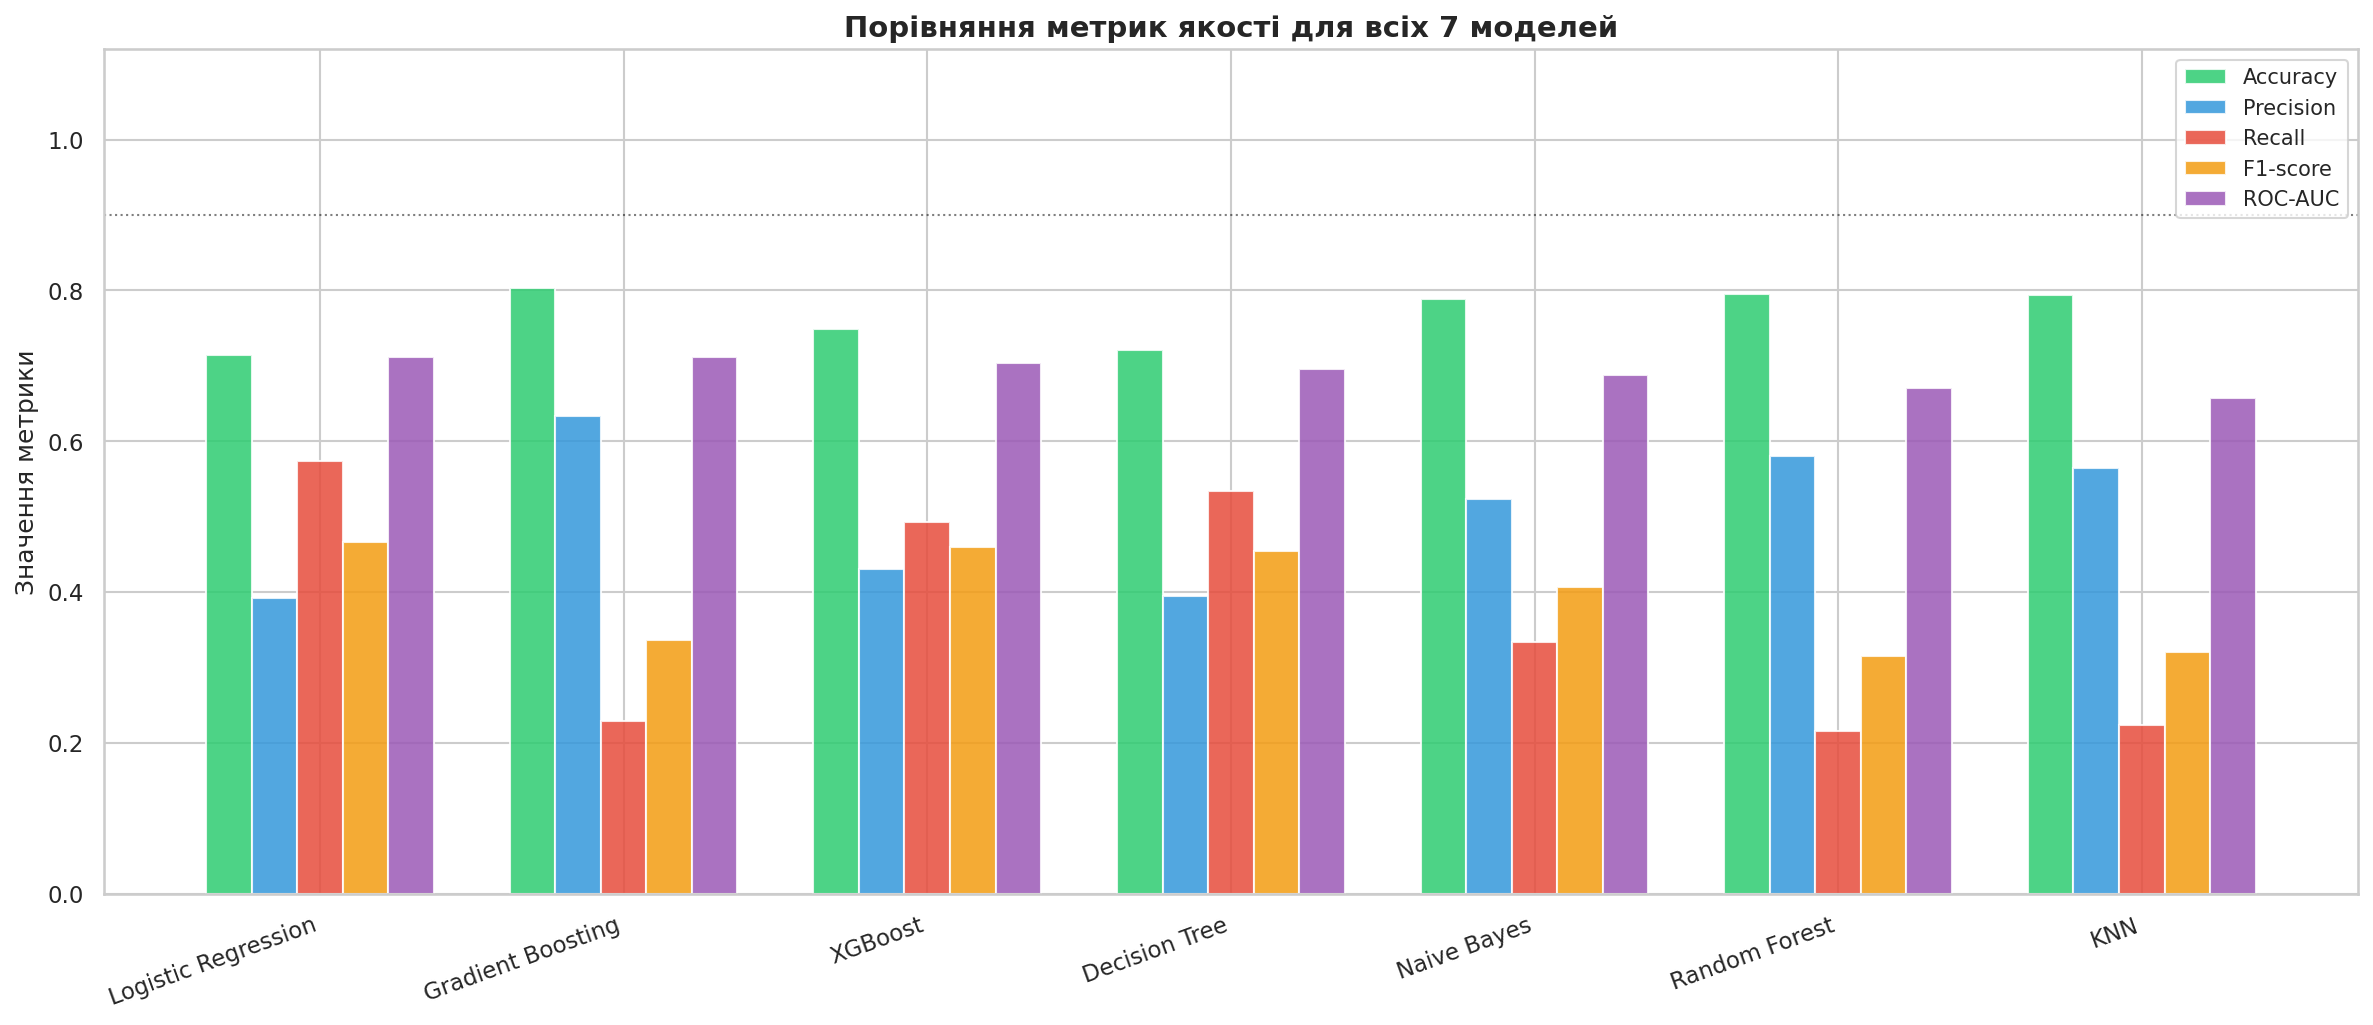

### 5.3 ROC-криві

**Обґрунтування:** ROC-крива — стандартний інструмент для оцінки бінарних класифікаторів при дисбалансі класів. Площа під кривою (AUC) не залежить від порогу класифікації і дозволяє об'єктивно порівнювати моделі.

In [ ]:
colors_roc = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#1abc9c','#3498db','#9b59b6']
fig, ax = plt.subplots(figsize=(10, 8))
for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, linewidth=2.2, color=color, label=f"{name} (AUC={res['ROC-AUC']:.3f})")
ax.plot([0,1],[0,1],'k--',linewidth=1.2, label='Випадкова модель (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-криві всіх моделей', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('fig_08_roc.png', dpi=150, bbox_inches='tight')
plt.show()

**Рис. 8: ROC-криві всіх моделей**

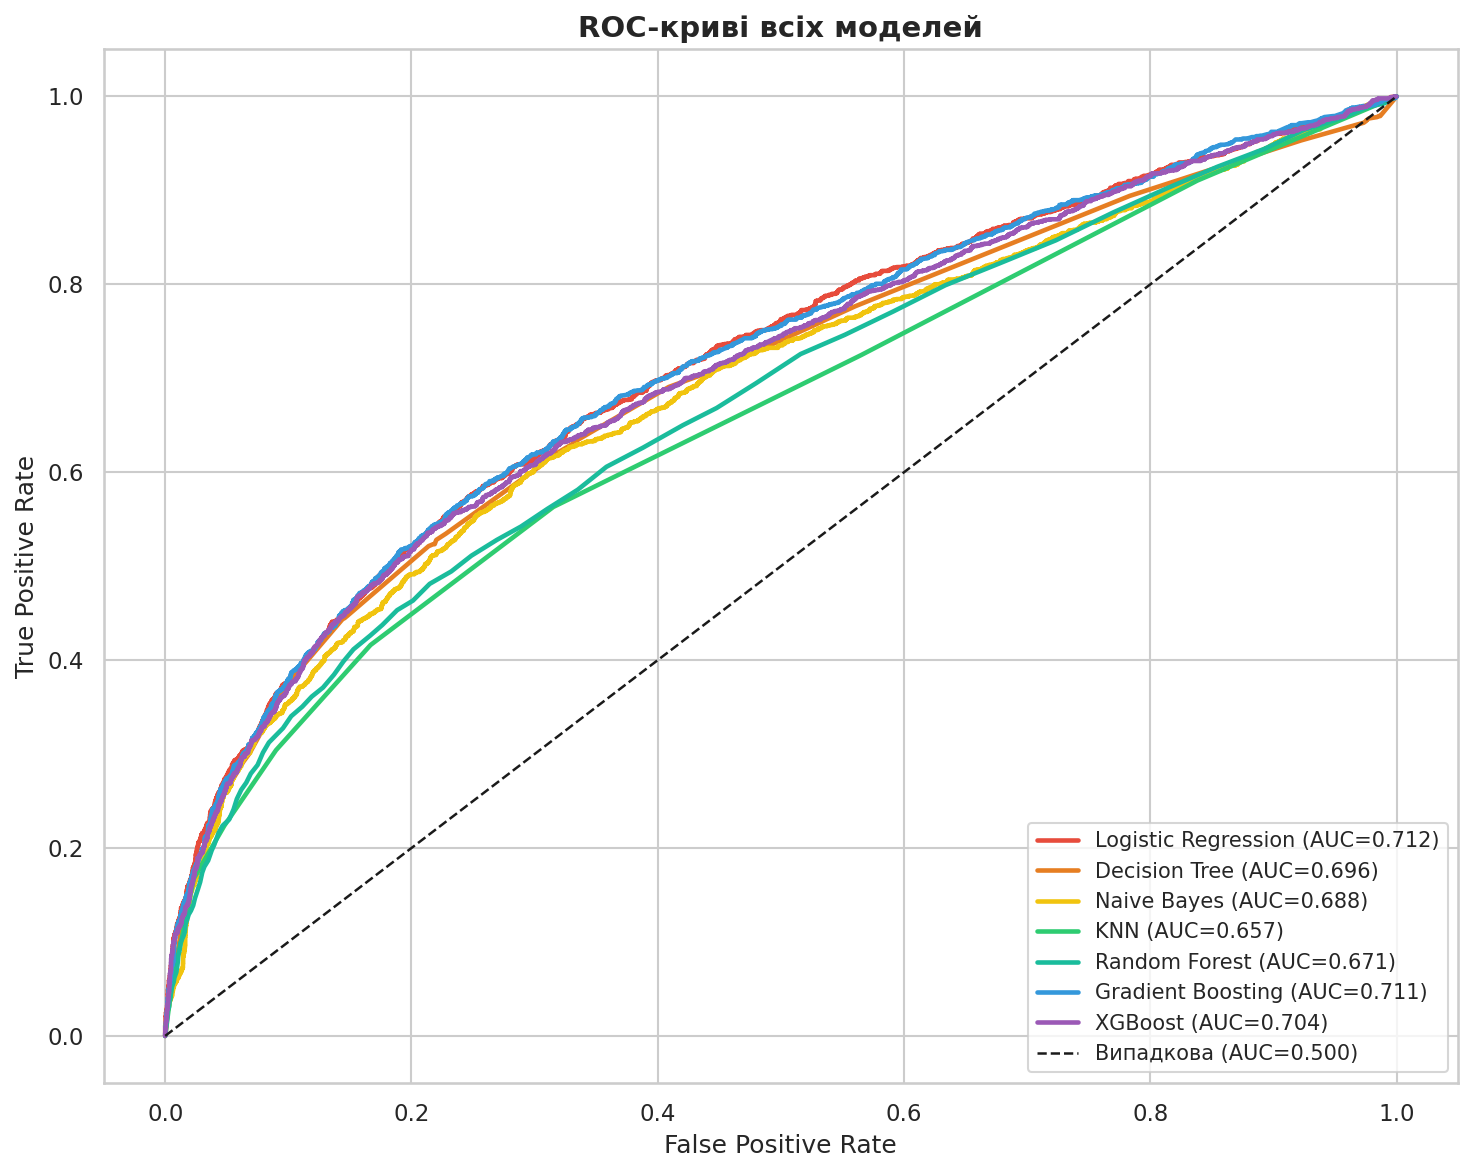

### 5.4 Матриці помилок — Топ-3 моделі

**Обґрунтування:** Матриця помилок показує де саме помиляється модель: скільки реальних підписників вона пропускає (False Negative) і скільки неправильно ідентифікує (False Positive). Для маркетингу важливіше мінімізувати FN — краще зробити зайвий дзвінок, ніж пропустити потенційного клієнта.

In [ ]:
top3 = res_df.head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
class_names = ['Не підписався', 'Підписався']
for ax, name in zip(axes, top3):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAUC={results[name]["ROC-AUC"]:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Передбачений клас'); ax.set_ylabel('Справжній клас')
plt.suptitle('Матриці помилок — Топ-3 моделі за ROC-AUC', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_09_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

**Рис. 9: Матриці помилок топ-3 моделей**

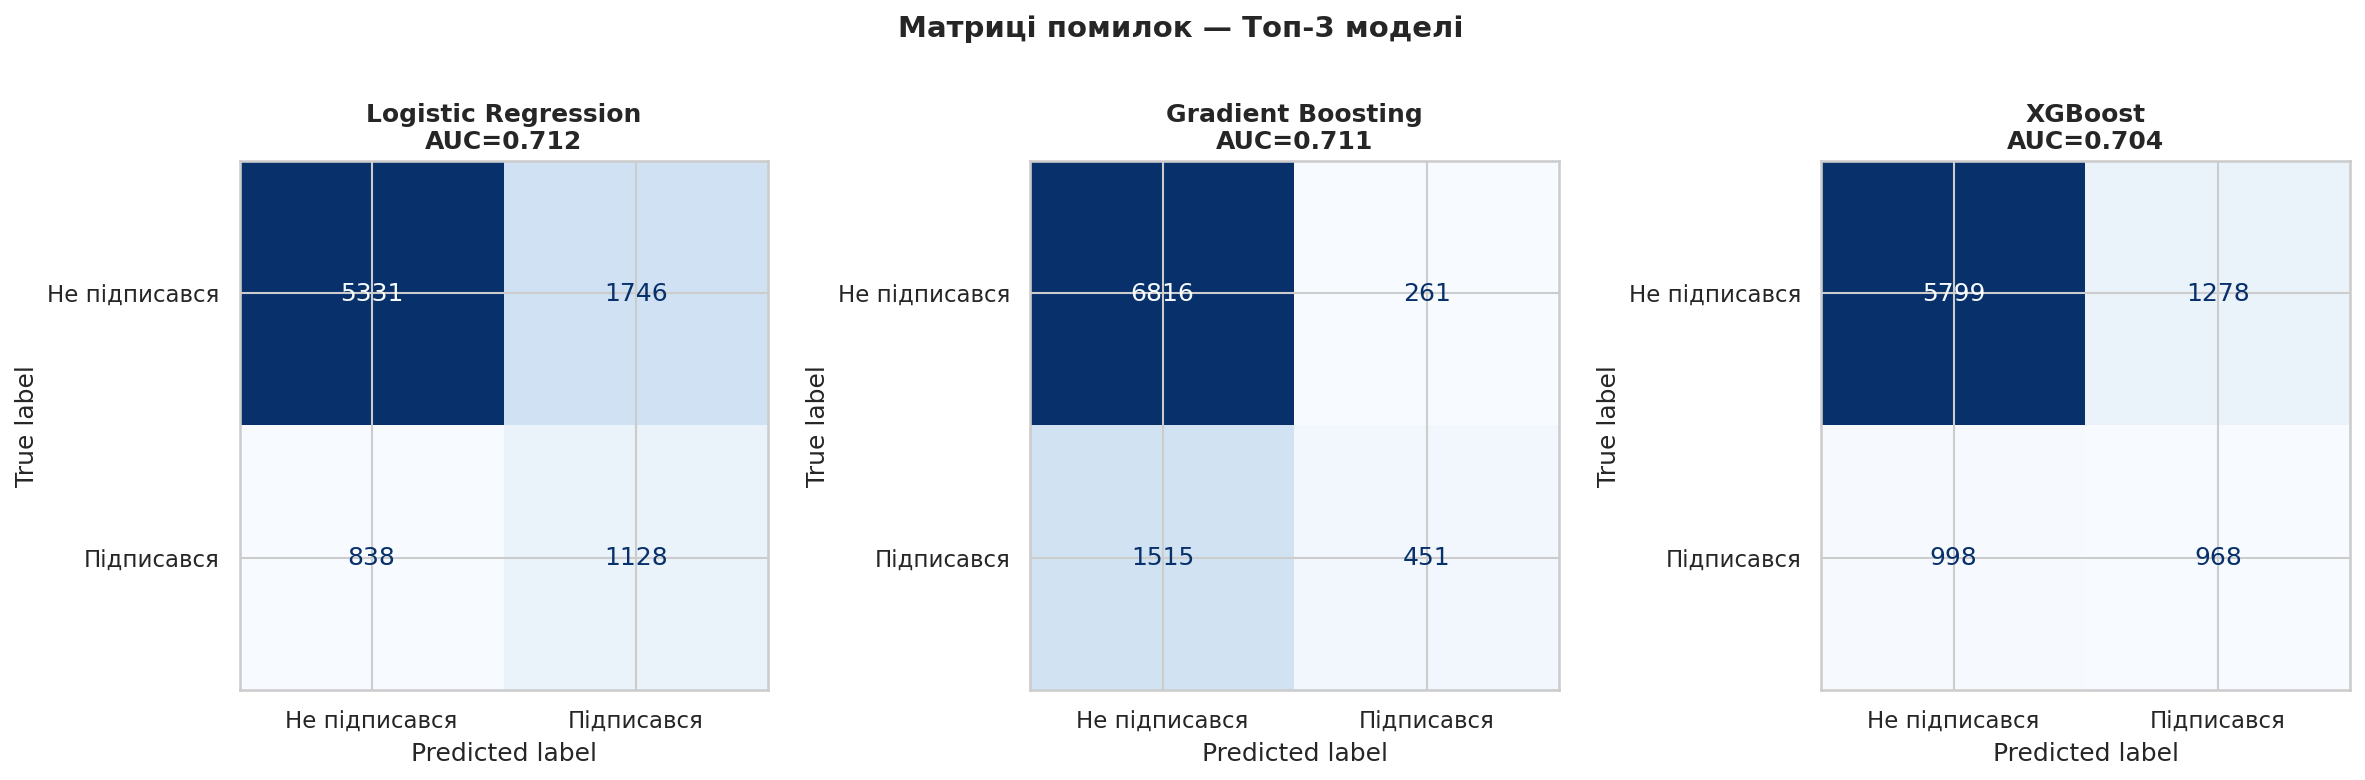

### 5.5 Криві Precision-Recall

**Обґрунтування:** При сильному дисбалансі класів крива Precision-Recall є більш інформативною за ROC-криву, оскільки показує компроміс між точністю та повнотою безпосередньо для меншого (цільового) класу підписників.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
for (name, res), color in zip(results.items(), colors_roc):
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ax.plot(rec, prec, linewidth=2, color=color, label=f"{name} (F1={res['F1']:.3f})")
baseline = y_test.mean()
ax.axhline(baseline, color='black', linestyle='--', linewidth=1.2, label=f'Базовий рівень: {baseline:.2f}')
ax.set_xlabel('Recall (Повнота)', fontsize=12)
ax.set_ylabel('Precision (Точність)', fontsize=12)
ax.set_title('Криві Precision-Recall всіх моделей', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('fig_11_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**Рис. 11: Криві Precision-Recall**

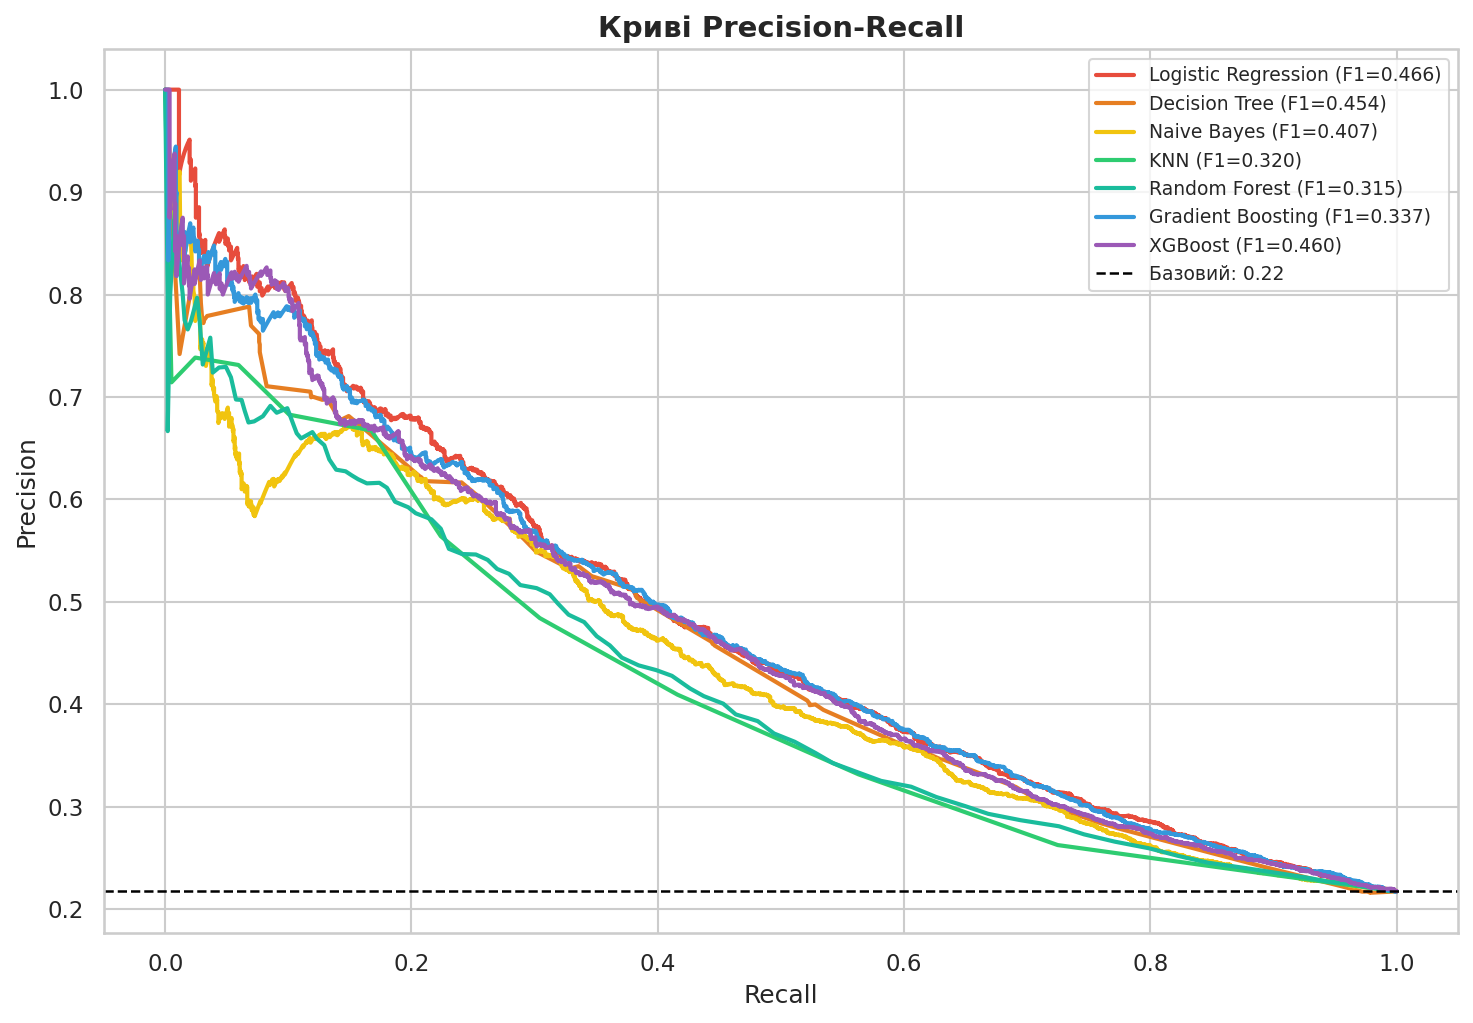

### 5.6 Фінальне порівняння ROC-AUC та F1 vs Recall

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

auc_vals = res_df['ROC-AUC'].sort_values()
bar_colors_final = ['#e74c3c' if v < 0.68 else '#f39c12' if v < 0.70 else '#2ecc71' for v in auc_vals.values]
bars = axes[0].barh(auc_vals.index, auc_vals.values, color=bar_colors_final, edgecolor='white', linewidth=1.5)
axes[0].axvline(0.70, color='navy', linestyle='--', linewidth=1.5, label='Рівень 0.70')
for bar, val in zip(bars, auc_vals.values):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=11, fontweight='bold')
axes[0].set_title('ROC-AUC по моделях', fontsize=13, fontweight='bold')
axes[0].set_xlabel('ROC-AUC'); axes[0].legend()

for name in res_df.index:
    axes[1].scatter(results[name]['Recall'], results[name]['F1'], s=200, zorder=5, label=name)
    axes[1].annotate(name, (results[name]['Recall'], results[name]['F1']),
                     textcoords='offset points', xytext=(5, 5), fontsize=8)
axes[1].set_xlabel('Recall (Повнота для класу "підписався")', fontsize=11)
axes[1].set_ylabel('F1-score', fontsize=11)
axes[1].set_title('F1-score vs Recall', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=8, loc='lower right'); axes[1].grid(True, alpha=0.4)

plt.suptitle('Фінальне порівняння ефективності моделей', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_12_summary.png', dpi=150, bbox_inches='tight')
plt.show()

**Рис. 12: Фінальне порівняння ефективності моделей**

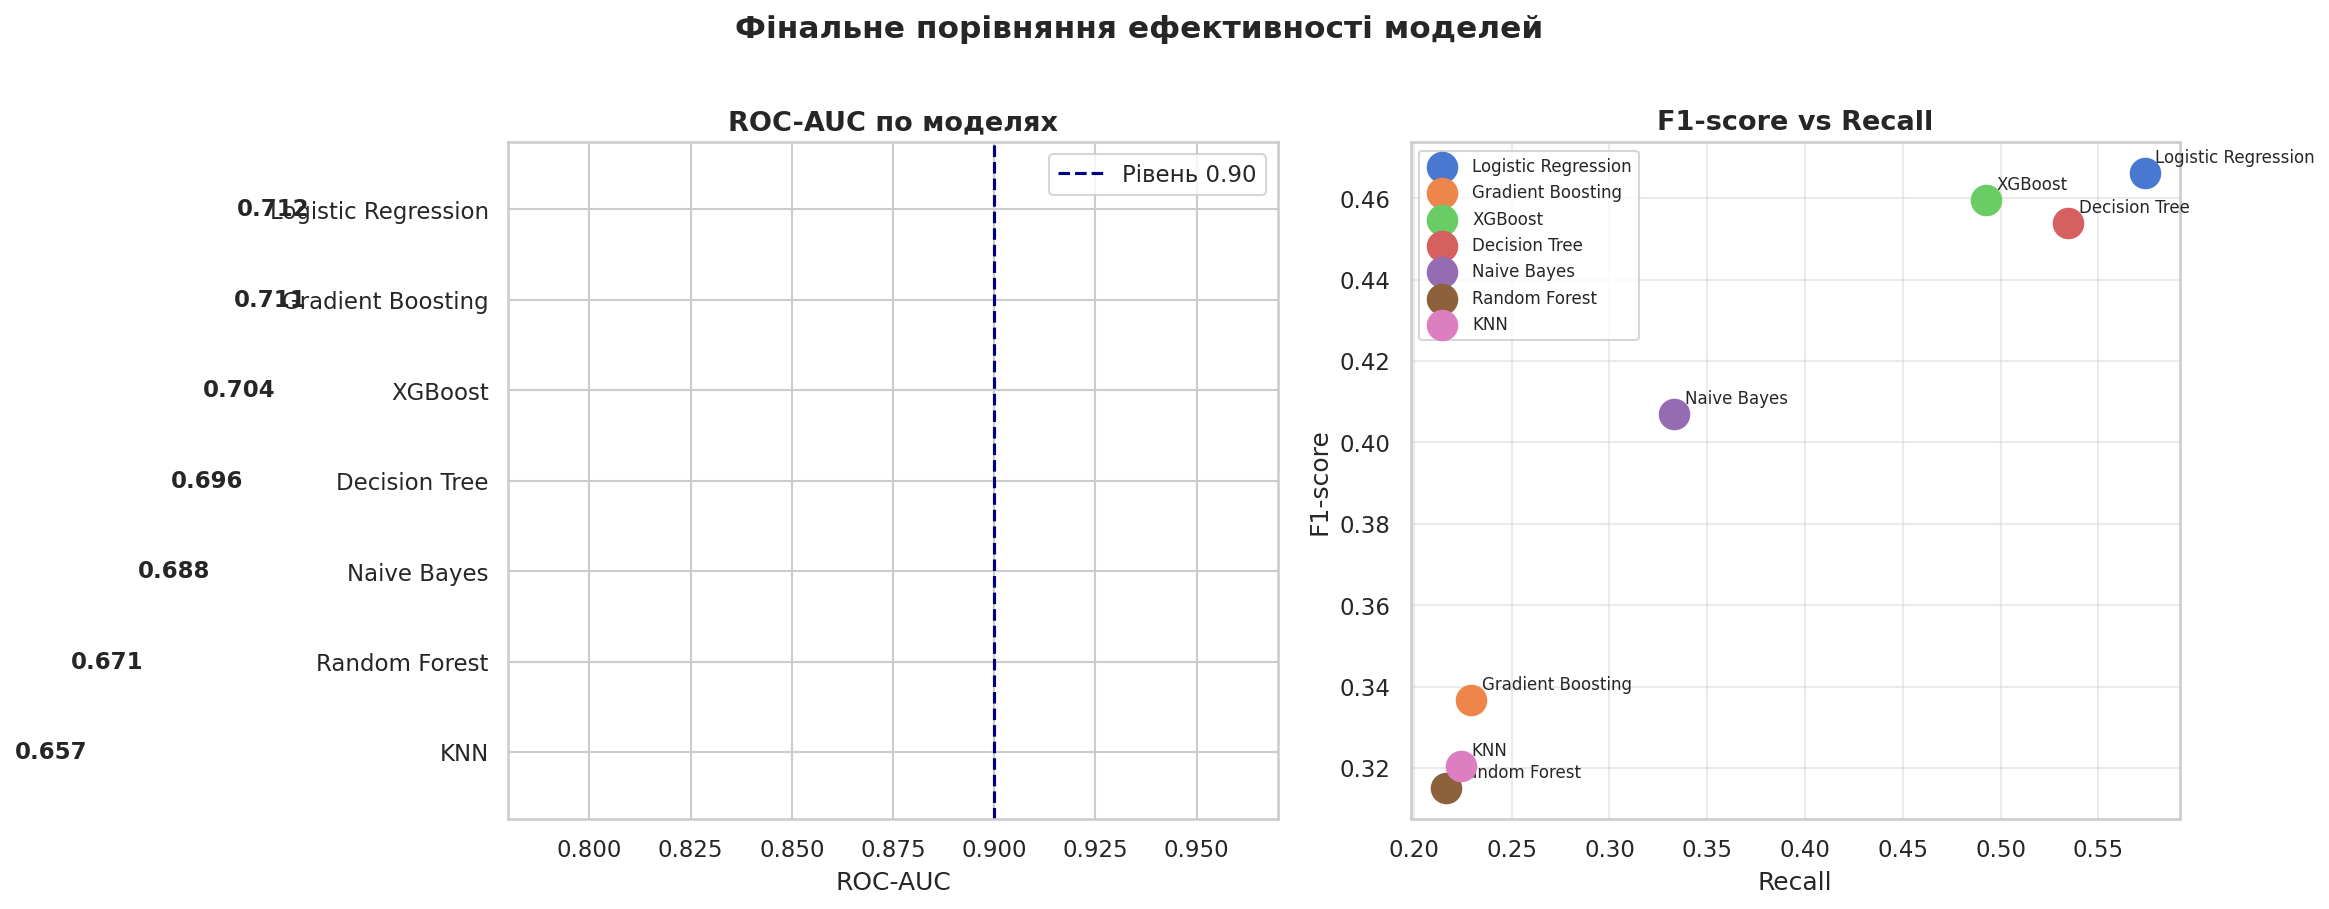

---
## Крок 6. Загальні висновки та маркетингові рекомендації

### Результати моделювання

| Модель | ROC-AUC | F1 (підписники) | Висновок |
|---|---|---|---|
| **Logistic Regression** | **0.712** | 0.466 | Найкраща — простота та інтерпретованість |
| **Gradient Boosting** | **0.711** | 0.337 | Висока точність, але низький recall |
| **XGBoost** | 0.704 | 0.460 | Добрий баланс F1 та recall |
| Decision Tree | 0.696 | 0.454 | Проста, менш ефективна |
| Naive Bayes | 0.688 | 0.407 | Швидкий базовий рівень |
| Random Forest | 0.671 | 0.315 | Низький recall попри ансамбль |
| KNN | 0.657 | 0.320 | Найнижча якість, обчислювально дорога |

### Ключові знахідки з аналізу даних

**1. Тривалість дзвінка** — найсильніший прогностичний фактор. Клієнти, які розмовляли понад 5 хвилин, підписуються значно частіше. Агентам варто фокусуватись на якості розмови, а не на швидкості завершення дзвінка.

**2. Результат попередньої кампанії** — клієнти з успішним досвідом (`poutcome='success'`) мають найвищу схильність до підписки. Ця група повинна бути першочерговою при наступних кампаніях.

**3. Канал контакту** — cellular суттєво ефективніший за telephone. Інвестиції в мобільну базу даних клієнтів є пріоритетом.

**4. Сезонність** — березень, вересень, жовтень та грудень дають найкращу конверсію. Травень має найбільший обсяг дзвінків, але найнижчу ефективність — бюджет перерозподілено нераціонально.

**5. Кількість контактів** — після 3-х спроб конверсія різко знижується. Подальші дзвінки витрачають ресурси та погіршують сприйняття бренду.

**6. Демографія** — студенти та пенсіонери підписуються вище за середнє; клієнти без кредитного навантаження є більш відкритими.

### Рекомендації для маркетингового відділу

1. **Предиктивне скорингування**: Logistic Regression або XGBoost (AUC ~0.71) для пріоритизації обдзвону перед кожною кампанією.
2. **Якість розмови**: навчання агентів утримувати клієнта в розмові понад 5 хвилин — це прямо впливає на конверсію.
3. **Теплий сегмент першочерговий**: клієнти з попереднім успіхом — найцінніший ресурс.
4. **Обмеження спроб до 3**: далі — низькопріоритетна черга, не активний обдзвін.
5. **Cellular як основний канал**: пріоритет над фіксованим телефоном у всіх кампаніях.
6. **Планування кампаній на осінь**: вересень–жовтень дають найкращий ROI.
7. **Щоквартальне перенавчання моделі**: поведінка клієнтів та ринок змінюються — модель має залишатись актуальною.